# 01 - Exploratory Data Analysis

**Project:** Causal Machine Learning for Breast Cancer Diagnosis

This notebook explores the Wisconsin Diagnostic Breast Cancer dataset before any causal or predictive modeling happens. All data loading and cleaning logic lives in the reusable `ml` package (`ml/data.py`) rather than being duplicated here, so this notebook and `app.py` / the FastAPI backend can never silently drift apart.

**Goal of this stage:** understand the shape, quality, and structure of the data - *before* we make any causal claims. Correlation and group differences shown here are purely descriptive (rung 1 of Pearl's Ladder of Causation, "seeing"); causal claims are reserved for notebook 02.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ml.data import load_dataset, clean_dataset
from ml.config import TARGET

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)

## 1. Load the data

`load_dataset()` reads `data/data.csv`, regenerating it deterministically from `sklearn.datasets.load_breast_cancer` (reshaped to the original Kaggle column layout) if it isn't present on disk yet.

In [2]:
raw_df = load_dataset()
raw_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal dimension_worst,Unnamed: 32
0,100488,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,100261,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,100224,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,100208,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,100231,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print(f'Shape: {raw_df.shape}')
print()
print(raw_df.dtypes.value_counts())
print()
print('Missing values per column (top 5):')
print(raw_df.isna().sum().sort_values(ascending=False).head())

Shape: (569, 33)

float64    31
int64       1
str         1
Name: count, dtype: int64

Missing values per column (top 5):
Unnamed: 32     569
id                0
diagnosis         0
texture_mean      0
radius_mean       0
dtype: int64


The only column with missing values is `Unnamed: 32`, a trailing artifact of the original Kaggle CSV export (every value is `NaN`). `clean_dataset` drops it along with the non-predictive `id` column, and encodes `diagnosis` as `1 = malignant, 0 = benign`.

In [4]:
df = clean_dataset(raw_df)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Class balance

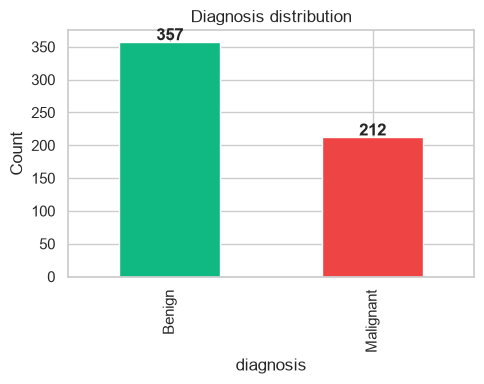

diagnosis
Benign       62.741652
Malignant    37.258348
Name: count, dtype: float64


In [5]:
counts = df[TARGET].value_counts().rename({1: 'Malignant', 0: 'Benign'})
ax = counts.plot(kind='bar', color=['#10b981', '#ef4444'], figsize=(5, 4))
ax.set_title('Diagnosis distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(counts / len(df) * 100)

The classes are moderately imbalanced (~63% benign / 37% malignant), which is why every downstream train/test split is stratified and ROC-AUC (threshold-independent) is tracked alongside accuracy.

## 3. Summary statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


## 4. Correlation structure

We restrict the heatmap to the `_mean` features for readability - the `_worst` and `_se` variants are highly collinear with them by construction (they describe the same physical cell measurements).

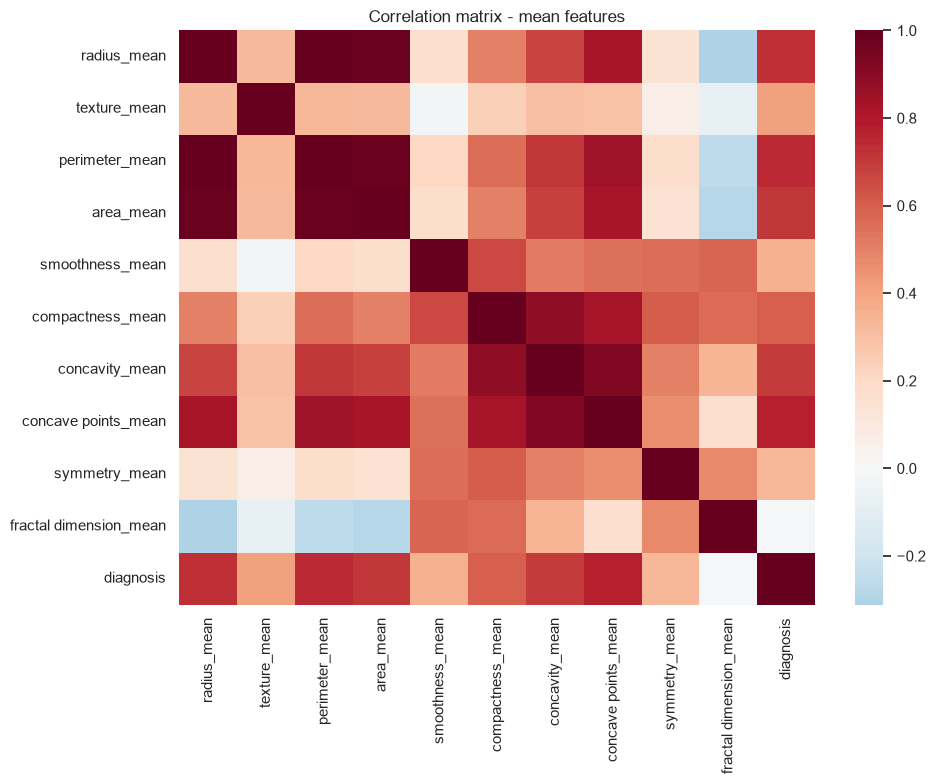

In [7]:
mean_cols = [c for c in df.columns if c.endswith('_mean')]
corr = df[mean_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax)
ax.set_title('Correlation matrix - mean features')
plt.tight_layout()
plt.show()

Several features are almost perfectly correlated with each other (`radius_mean` / `perimeter_mean` / `area_mean`), exactly as geometry predicts (perimeter ~ 2*pi*r, area ~ pi*r^2). This multicollinearity is precisely why a single correlation number cannot tell us *which* of these mechanically-linked features is doing the causal work - motivating the explicit causal graph built in notebook 02.

## 5. Feature distributions by diagnosis

Effect size (Cohen's d) alongside the visual spread, for the five features most correlated with diagnosis.

In [8]:
top_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(5)
top_corr

concave points_mean    0.776614
perimeter_mean         0.742636
radius_mean            0.730029
area_mean              0.708984
concavity_mean         0.696360
Name: diagnosis, dtype: float64

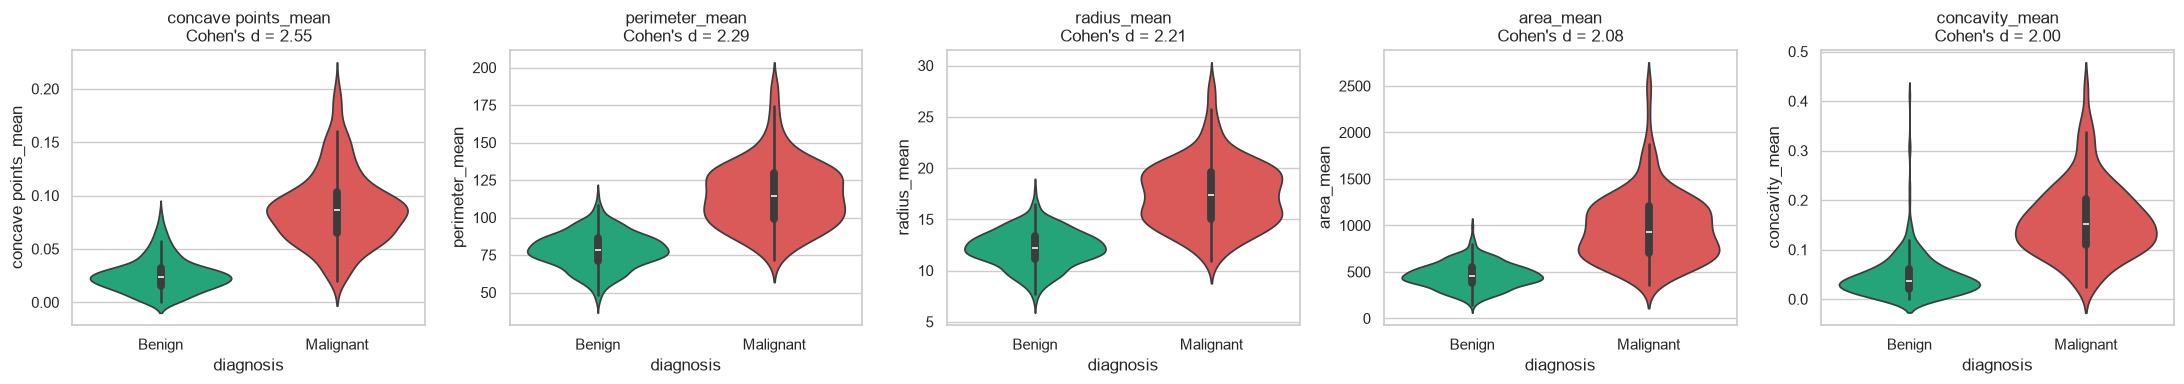

In [9]:
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1 - 1) * a.var() + (n2 - 1) * b.var()) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_std

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, feature in zip(axes, top_corr.index):
    sns.violinplot(data=df, x=TARGET, y=feature, ax=ax, hue=TARGET, palette=['#10b981', '#ef4444'], legend=False)
    d = cohens_d(df.loc[df[TARGET] == 1, feature], df.loc[df[TARGET] == 0, feature])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_title(f'{feature}\nCohen\'s d = {d:.2f}')
plt.tight_layout()
plt.show()

All five show a large effect size (|d| > 0.8) with malignant tumors systematically larger and more irregular. This confirms the features the statistical causal-score step (notebook 02) also ranks highly.

## 6. Takeaways into notebook 02

- No missing data to impute once export artifacts are dropped.
- Moderate class imbalance -> stratified splits, ROC-AUC as the primary metric.
- Heavy multicollinearity among geometrically related features -> a single correlation coefficient is not enough to reason about *causal* structure; we need an explicit DAG and Pearl's backdoor-adjustment criterion, which is exactly what notebook 02 builds.